In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Loading data and cleaning it

In [2]:
from datasets import load_from_disk

dataset = load_from_disk("data/language_identification")
dataset

d:\anaconda\envs\nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

In [3]:
df = dataset["train"].to_pandas()
df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [4]:
df.isnull().sum()

labels    0
text      0
dtype: int64

In [5]:
df["labels"].nunique()

20

In [6]:
df["labels"].value_counts()

labels
pt    3500
bg    3500
zh    3500
th    3500
ru    3500
pl    3500
ur    3500
sw    3500
tr    3500
es    3500
ar    3500
it    3500
hi    3500
de    3500
el    3500
nl    3500
fr    3500
vi    3500
en    3500
ja    3500
Name: count, dtype: int64

In [7]:
df.describe()

,labels,text
count,70000,70000
unique,20,68978
top,pt,Een man speelt gitaar.
freq,3500,18


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


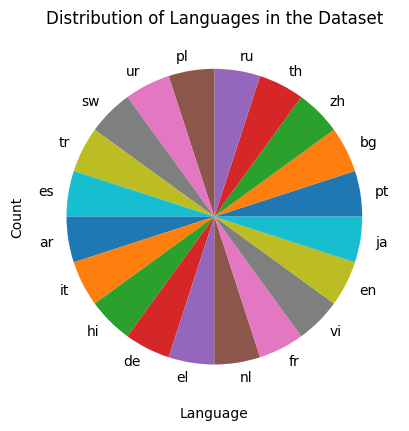

In [9]:
import matplotlib.pyplot as plt
df["labels"].value_counts().plot(kind="pie")
plt.xlabel("Language")
plt.ylabel("Count")
plt.title("Distribution of Languages in the Dataset")
plt.show()

## Creating dataloader for model

In [10]:
import torch
from torch.utils.data import DataLoader, Dataset

class DistillationDataset(Dataset):
    def __init__(self, encoded_hf_dataset):
        """ takes encoded dataset from HuggingFace and prepares it for distillation """
        self.input_ids = encoded_hf_dataset["input_ids"]
        self.attention_mask = encoded_hf_dataset["attention_mask"]
        self.labels = encoded_hf_dataset["labels"]
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
			"input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
			"attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
			"labels": torch.tensor(self.labels[idx], dtype=torch.long)
		}

def prepare_dataset(batch):
    tokenized = tokenizer(
        batch["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )
    tokenized["labels"] = [label2id[label] for label in batch["labels"]]
    return tokenized

In [11]:
from transformers import AutoTokenizer
model = "papluca/xlm-roberta-base-language-detection"
tokenizer = AutoTokenizer.from_pretrained(model)
labels = dataset["train"].unique("labels")
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

In [12]:
encoded_dataset = dataset.map(prepare_dataset, batched=True)
encoded_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [13]:
train_dataset = DistillationDataset(encoded_dataset["train"])
val_dataset = DistillationDataset(encoded_dataset["validation"])
test_dataset = DistillationDataset(encoded_dataset["test"])

batch_size = 16
train_dataloader = DataLoader(
    train_dataset,
	batch_size=batch_size,
	shuffle=True,
    pin_memory=True
)
val_dataloader = DataLoader(
	val_dataset,
	batch_size=batch_size,
	shuffle=False,
	pin_memory=True
)
test_dataloader = DataLoader(
	test_dataset,
	batch_size=batch_size,
	shuffle=False,
	pin_memory=True
)
print(f"train batches: {len(train_dataloader)}")
print(f"validation batches: {len(val_dataloader)}")
print(f"test batches: {len(test_dataloader)}")

train batches: 4375
validation batches: 625
test batches: 625


In [14]:
for batch in train_dataloader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    
    print("Batch Input IDs shape:", input_ids.shape)       # Expected: [16, 128]
    print("Batch Attention Mask shape:", attention_mask.shape) # Expected: [16, 128]
    print("Batch Labels shape:", labels.shape)             # Expected: [16]
    break

Batch Input IDs shape: torch.Size([16, 128])
Batch Attention Mask shape: torch.Size([16, 128])
Batch Labels shape: torch.Size([16])


C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "labels": torch.tensor(self.labels[idx], dtype=torch.long)


## preparing model and tokenizer for training

In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "models/xlm-roberta-lang-classifier"
teacher_model = AutoModelForSequenceClassification.from_pretrained(model_name)
teacher_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"model loaded: {model_name}")
print(f"tokenizer loaded: {model_name}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8307.43it/s]


model loaded: models/xlm-roberta-lang-classifier
tokenizer loaded: models/xlm-roberta-lang-classifier


In [16]:
from transformers import pipeline
teacher_pipeline = pipeline(
	"text-classification",
	model=teacher_model,
	tokenizer=tokenizer,
)
result = teacher_pipeline("This is a test sentence.")
print(result)

[{'label': 'en', 'score': 0.9867674708366394}]


## PEFT configs for lora training

In [17]:
def freeze_teacher_model(model):
    for param in model.parameters():
        param.requires_grad = False

freeze_teacher_model(teacher_model)
                

In [18]:
import torch
import evaluate
from peft import LoraConfig, get_peft_model, TaskType
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
datacollator = DataCollatorWithPadding(tokenizer=tokenizer)
metric = evaluate.load("f1")
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Sequence Classification
    r=8,                        # Rank of the adapter
    lora_alpha=32,               # Scaling factor
    target_modules=["query", "key", "value"],
    lora_dropout=0.05,
    bias="none",
)
teacher_model_lora = get_peft_model(teacher_model, peft_config)
teacher_model_lora.print_trainable_parameters()

W0512 19:30:29.722000 29168 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


trainable params: 1,048,340 || all params: 279,107,368 || trainable%: 0.3756


In [19]:
def compute_metrics(eval_pred):
	logits, labels = eval_pred
	predictions = torch.argmax(torch.tensor(logits), dim=-1)
	return metric.compute(predictions=predictions, references=labels, average="macro")

## training model and evaluating it

In [24]:
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="models/teacher_model_lora",
	num_train_epochs=20,
	per_device_train_batch_size=16,
	per_device_eval_batch_size=16,
	eval_strategy="epoch",
	save_strategy="epoch",
	load_best_model_at_end=True,
	metric_for_best_model="f1",
)
trainer = Trainer(
	model=teacher_model_lora,
	args=training_args,
	train_dataset=train_dataset,
	eval_dataset=val_dataset,
	compute_metrics=compute_metrics,
	data_collator=datacollator,
	callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)


In [25]:
print("Training teacher model with LoRA...")
trainer.train()

print("Final Evaluation:")
print(trainer.evaluate())

teacher_model.save_pretrained("./final_peft_teacher_model")
tokenizer.save_pretrained("./final_peft_teacher_model")
print("Teacher successfully saved!")

Training teacher model with LoRA...


C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "labels": torch.tensor(self.labels[idx], dtype=torch.long)


Epoch,Training Loss,Validation Loss,F1
1,0.007868,0.012836,0.997396
2,0.008061,0.011086,0.997497
3,0.007979,0.018411,0.997397
4,0.005806,0.017636,0.997297
5,0.004885,0.017001,0.996998


C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "labels": torch.tensor(self.labels[idx], dtype=torch.long)
C

Final Evaluation:


C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
C:\Users\basil\AppData\Local\Temp\ipykernel_29168\1052647000.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "labels": torch.tensor(self.labels[idx], dtype=torch.long)


Training Loss,Validation Loss,Epoch,F1
0.004885,0.011086,5,0.997497


{'eval_loss': 0.011085938662290573, 'eval_f1': 0.9974967737254861}


Writing model shards: 100%|██████████| 1/1 [00:10<00:00, 10.12s/it]

Teacher successfully saved!
